In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License"); { display-mode: "form" }
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# HMC, SGMCMC and MFVI on Synthetic Regression

In [2]:
import os
import sys
from jax import config
import haiku as hk
import jax
from jax import numpy as jnp
import numpy as onp
import time
# from jax.experimental.callback import rewrite
import tqdm
import copy
sys.path.append("../")
from utils import data_utils
from utils import models
from utils import losses
from utils import checkpoint_utils
# from utils import cmd_args_utils
# from utils import logging_utils
from utils import train_utils
from utils import tree_utils
from utils import precision_utils
from utils import optim_utils

import optax
import functools

from matplotlib import pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

2025-01-04 14:51:35.940779: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-04 14:51:35.967038: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-04 14:51:35.975163: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-04 14:51:37.450277: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
# tpu_ip = "10.0.0.2"
# config.FLAGS.jax_xla_backend = "tpu_driver"
# config.FLAGS.jax_backend_target = "grpc://{}:8470".format(tpu_ip)
train_utils.set_up_jax(None, False)

2025-01-04 14:51:39.624995: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Data

In [4]:
data_npz = onp.load("synth_reg_data.npz")
x_ = jnp.asarray(data_npz["x_"])
y_ = jnp.asarray(data_npz["y_"])
f_ = jnp.asarray(data_npz["f_"])
x = jnp.asarray(data_npz["x"])
y = jnp.asarray(data_npz["y"])
f = jnp.asarray(data_npz["f"])

data_info = {"y_scale": 1.}

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [5]:
def inv_softplus(x):
    return jnp.log(jnp.exp(x) - 1)

# Noise in the data
noise_std = 0.02
invsp_noise_std = inv_softplus(noise_std)

In [45]:
y.shape

(120, 1)

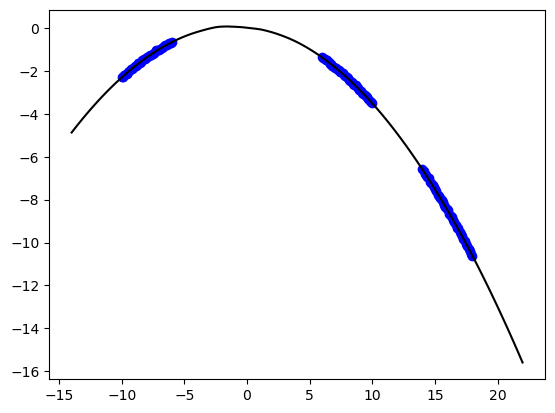

In [6]:
plt.plot(x, y, "bo")
plt.plot(x_, y_, "-k")

In [39]:
num_devices = len(jax.devices())
train_set = (f, y)
test_set = (f_, y_)
train_set = data_utils.pmap_dataset(train_set, num_devices)
test_set = data_utils.pmap_dataset(test_set, num_devices)

## Model

In [40]:
def make_model(layer_dims, invsp_noise_std):
    def forward(batch, is_training):
        x, _ = batch
        x = hk.Flatten()(x)
        for layer_dim in layer_dims:
            x = hk.Linear(layer_dim)(x)
            x = jax.nn.relu(x)
        x = hk.Linear(1)(x)
        x = jnp.concatenate([x, jnp.ones_like(x) * invsp_noise_std], -1)
        return x
    return forward

In [9]:
# net_fn = models.make_mlp_regression(data_info, output_dim=1, layer_dims=[100, 100, 100])
hidden_sizes = [50]
net_fn = make_model(layer_dims=hidden_sizes, invsp_noise_std=invsp_noise_std)
net = hk.transform_with_state(net_fn)
net_apply, net_init = net.apply, net.init
net_apply = precision_utils.rewrite_high_precision(net_apply)

In [10]:
# key, net_init_key = jax.random.split(jax.random.PRNGKey(0), 2)
# start_iteration = 0
# num_ensembled = 0
# ensemble_predictions = None
# step_size = 1.e-4

In [11]:
def resample_params(seed, params, std=0.005):
    key = jax.random.PRNGKey(seed)
    num_leaves = len(jax.tree.leaves(params))
    normal_keys = list(jax.random.split(key, num_leaves))
    treedef = jax.tree.structure(params)
    normal_keys = jax.tree.unflatten(treedef, normal_keys)
    params = jax.tree_map(lambda p, k: jax.random.normal(k, p.shape) * std,
                               params, normal_keys)
    return params

In [12]:
param_seed = 2
params, net_state = net.init(jax.random.PRNGKey(param_seed), (f, None), True)
params = resample_params(param_seed, params)
net_state = jax.pmap(lambda _: net_state)(jnp.arange(num_devices))

/tmp/ipykernel_3862934/4056984114.py:7: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  params = jax.tree_map(lambda p, k: jax.random.normal(k, p.shape) * std,


## Prior and likelihood

In [13]:
prior_std = 0.1
weight_decay = 1 / prior_std**2

task = data_utils.Task("regression")
(likelihood_factory, predict_fn, ensemble_upd_fn, _,_) = train_utils.get_task_specific_fns(task, data_info)
log_prior_fn, log_prior_diff_fn = losses.make_gaussian_log_prior(weight_decay, 1.)

True task
Task.REGRESSION data_utils.Task.REGRESSION


In [14]:
log_prior_fn, log_prior_diff_fn = (
    losses.make_gaussian_log_prior(weight_decay, 1.))
log_likelihood_fn = losses.make_gaussian_likelihood(1.)

## HMC
### HMC update

In [15]:
step_size = 1e-5
trajectory_len = jnp.pi / 2 / jnp.sqrt(weight_decay)
max_num_leapfrog_steps = int(trajectory_len // step_size + 1)
print("Leapfrog steps per iteration:", max_num_leapfrog_steps)

Leapfrog steps per iteration: 15708


In [16]:
update, get_log_prob_and_grad = train_utils.make_hmc_update(
    net_apply, log_likelihood_fn, log_prior_fn, log_prior_diff_fn,
    max_num_leapfrog_steps, 1., 0.)

In [17]:
# Initial log-prob and grad values
log_prob, state_grad, log_likelihood, net_state = (
    get_log_prob_and_grad(train_set, params, net_state))

### Run HMC

In [18]:
num_iterations = 100
log_likelihoods = []
all_test_preds = []
key = jax.random.PRNGKey(0)

for iteration in tqdm.tqdm(range(num_iterations)):
    
#     in_burnin = (iteration < args.num_burn_in_iterations)
#     do_mh_correction = (not args.no_mh) and (not in_burnin)

    (params, net_state, log_likelihood, state_grad, step_size, key,
     accept_prob, accepted) = (
        update(train_set, params, net_state, log_likelihood, state_grad,
               key, step_size, trajectory_len, True))
    # Evaluation
    test_predictions = onp.asarray(
      predict_fn(net_apply, params, net_state, test_set)[1])
    if accepted:
        all_test_preds.append(test_predictions)
        log_likelihoods.append(log_likelihood)

    print("It: {} \t Accept P: {} \t Accepted {} \t Log-likelihood: {}".format(
            iteration, accept_prob, accepted, log_likelihood))

  1%|          | 1/100 [00:02<03:39,  2.22s/it]

It: 0 	 Accept P: 0.0 	 Accepted False 	 Log-likelihood: -4155577.0


  2%|▏         | 2/100 [00:04<03:36,  2.20s/it]

It: 1 	 Accept P: 0.0 	 Accepted False 	 Log-likelihood: -4155577.0


  3%|▎         | 3/100 [00:07<03:52,  2.40s/it]

...

It: 97 	 Accept P: 0.9771879315376282 	 Accepted True 	 Log-likelihood: 304.05059814453125


 99%|█████████▉| 99/100 [03:28<00:01,  1.92s/it]

It: 98 	 Accept P: 1.0 	 Accepted True 	 Log-likelihood: 300.4189758300781


100%|██████████| 100/100 [03:30<00:00,  2.10s/it]

It: 99 	 Accept P: 0.8822165727615356 	 Accepted True 	 Log-likelihood: 301.49212646484375


In [19]:
# log_likelihoods = [float(log_likelihood) for log_likelihood in log_likelihoods]

In [20]:
import pickle
with open("log_likelihoods.pkl","rb") as f:
    log_likelihoods = pickle.load(f)

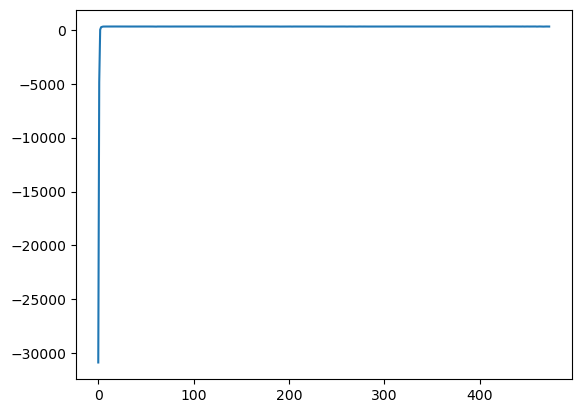

In [21]:
plt.plot(log_likelihoods)
plt.show()

In [22]:
# import pickle
# with open("log_likelihoods.pkl","wb") as f:
#     pickle.dump(log_likelihoods, f)

In [23]:
# preds_concat = onp.concatenate(all_test_preds, axis=0)
# onp.save("preds_concat.npy", preds_concat)

In [24]:
preds_concat = onp.load("preds_concat.npy")

In [25]:
preds_concat = preds_concat[3:]

In [26]:
preds_concat.shape

(45, 120, 2)

In [27]:
pred_mean = onp.mean(preds_concat, axis=0)[:, 0]
pred_std = onp.std(preds_concat, axis=0)[:, 0]

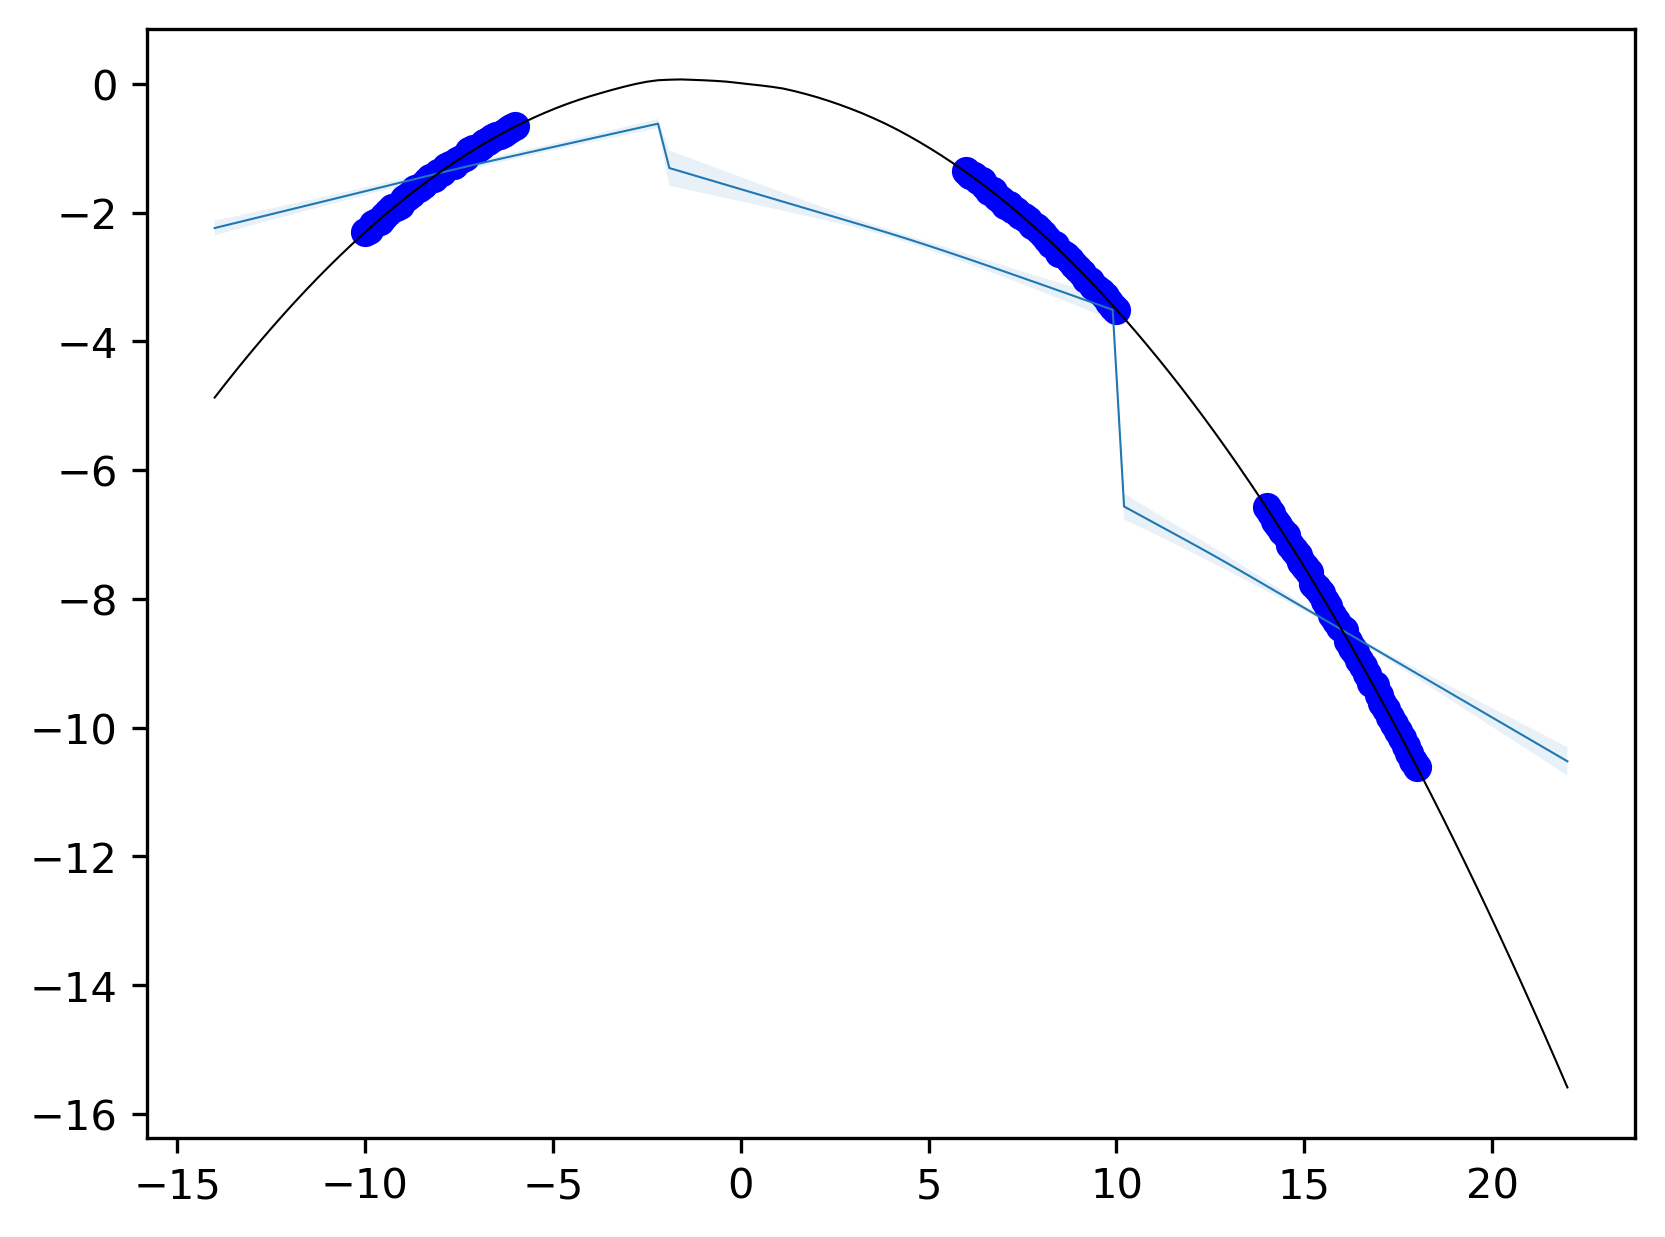

In [28]:
plt.figure(dpi=300)
plt.plot(x, y, "bo")
plt.plot(x_, pred_mean, linewidth=0.5)
plt.plot(x_, y_, color='black', linewidth=0.5)
plt.fill_between(x_, pred_mean-3*pred_std, pred_mean+3*pred_std, alpha=0.1)
plt.show()

noise_FCN

In [29]:
import torch
import torch.nn as nn
sys.path.append("/home/xueqiong/noise_injection_uncertainty/regression")
from networks import FullyConnectedNN, NoisyFullyConnectedNN, FixNoiseFullyConnectedNN, DropoutFullyConnectedNN
import shutil

In [30]:
train_set, test_set

((Array([[[-10.       , 100.       ],
          [ -9.897436 ,  97.95924  ],
          [ -9.794872 ,  95.93952  ],
          [ -9.692307 ,  93.94083  ],
          [ -9.589744 ,  91.96318  ],
          [ -9.48718  ,  90.00658  ],
          [ -9.384616 ,  88.071014 ],
          [ -9.282051 ,  86.15647  ],
          [ -9.179487 ,  84.262985 ],
          [ -9.076923 ,  82.39054  ],
          [ -8.9743595,  80.53913  ],
          [ -8.871795 ,  78.70874  ],
          [ -8.769231 ,  76.89941  ],
          [ -8.666667 ,  75.111115 ],
          [ -8.564103 ,  73.343864 ],
          [ -8.461538 ,  71.59763  ],
          [ -8.358974 ,  69.87245  ],
          [ -8.256411 ,  68.16832  ],
          [ -8.153846 ,  66.4852   ],
          [ -8.051282 ,  64.82314  ],
          [ -7.948718 ,  63.182117 ],
          [ -7.846154 ,  61.562138 ],
          [ -7.74359  ,  59.963184 ],
          [ -7.641026 ,  58.385277 ],
          [ -7.5384617,  56.828403 ],
          [ -7.4358974,  55.29257  ],
          [ 

In [31]:
X_train = torch.tensor(train_set[0]._npy_value, dtype=torch.float32)
y_train = torch.tensor(train_set[1]._npy_value, dtype=torch.float32)
X_test = torch.tensor(test_set[0]._npy_value, dtype=torch.float32)
y_test = torch.tensor(test_set[1]._npy_value, dtype=torch.float32)

In [32]:
X_train = X_train.squeeze(0)
y_train = y_train.squeeze(0)
X_test = X_test.squeeze(0)
y_test = y_test.squeeze(0)

In [33]:
train_data = torch.utils.data.TensorDataset(X_train, y_train)
test_data = torch.utils.data.TensorDataset(X_test, y_test)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=X_train.shape[0], shuffle=True, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=5, shuffle=False, num_workers=4)

In [34]:
def train(model, train_loader, optimizer, criterion):
    model.train()
    losses = AverageMeter()
    for inputs, labels in train_loader:
        if use_cuda:
            labels = labels.cuda()
            inputs = inputs.cuda()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        losses.update(loss.item(), inputs.size(0))
    return losses.avg

def validate(model, val_loader, criterion, test_times=100, use_cuda=False):
    model.eval()
    if 'Dropout' in model._get_name():
        recursive_module_iteration(model)
    losses = AverageMeter()
    with torch.no_grad():
        var_outputs_all = []
        pred_all = []
        for inputs, labels in val_loader:
            outputs = torch.zeros((inputs.shape[0], 1, test_times))
            if use_cuda:
                labels = labels.cuda()
                inputs = inputs.cuda()
                outputs = outputs.cuda()
            # compute output
            for i in range(test_times):
                output = model(inputs)
                outputs[:, :, i] = output
            avg_outputs = torch.mean(outputs, dim=2)
            var_outputs = torch.sum(torch.var(outputs, dim=2), dim=-1)
            loss = criterion(avg_outputs, labels)
            losses.update(loss.item(), inputs.size(0))
            if use_cuda:
                var_outputs = var_outputs.cpu()
                avg_outputs = avg_outputs.cpu()
            var_outputs = var_outputs.numpy().tolist()
            var_outputs_all.extend(var_outputs)
            avg_outputs = avg_outputs.numpy().tolist()
            pred_all.extend(avg_outputs)
            
    return losses.avg, var_outputs_all, pred_all

class AverageMeter(object):
  """Computes and stores the average and current value"""
  def __init__(self):
    self.reset()

  def reset(self):
    self.val = 0
    self.avg = 0
    self.sum = 0
    self.count = 0

  def update(self, val, n=1):
    self.val = val
    self.sum += val * n
    self.count += n
    self.avg = self.sum / self.count

In [35]:
def def_optm(optimizer_name):
    global normal_param, learning_rate, momentum, weight_decay
    if optimizer_name == "SGD":
        print("using SGD as optimizer")
        optimizer = torch.optim.SGD([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate,
                                    momentum=momentum, weight_decay=weight_decay,
                                    nesterov=True)

    elif optimizer_name == "Adam":
        print("using Adam as optimizer")
        optimizer = torch.optim.Adam([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate,
                                    weight_decay=weight_decay)
    elif optimizer_name == "RMSprop":
        print("using RMSprop as optimizer")
        optimizer = torch.optim.RMSprop([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate, alpha=0.99, eps=1e-08, weight_decay=weight_decay, momentum=0)
    return optimizer

def def_model(model_name, input_size, hidden_sizes, output_size):
    print('model_name', model_name)
    if model_name == 'FCN':
        net = FullyConnectedNN(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size)
    elif model_name == 'noisyFCN':
        net = NoisyFullyConnectedNN(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size, init_noiselevel=init_noiselevel)
    elif model_name == 'fixnoiseFCN':
        net = FixNoiseFullyConnectedNN(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size, fix_noiselevel=fix_noiselevel)
    elif model_name == 'dropoutFCN':
        net = DropoutFullyConnectedNN(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size, dropout_prob=dropout_prob)
    return net

def get_save_path():
    global model_name, fix_noiselevel, init_noiselevel, dropout_prob, dataset_path, batch_size, learning_rate, optimizer_name
    if model_name == 'fixnoiseFCN':
        model_name2 = model_name + '_{}'.format(fix_noiselevel)
    elif model_name == 'noisyFCN':
        model_name2 = model_name + '_{}'.format(init_noiselevel)
    elif model_name == 'dropoutFCN':
        model_name2 = model_name + '_{}'.format(dropout_prob)
    else:
        model_name2 = model_name
    save_path = os.path.join('save_model', model_name2+'_bs_{}_lr_{}_wd{}_optm_{}'.format(batch_size, learning_rate, weight_decay, optimizer_name))
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    return save_path

def save_checkpoint(state, is_best, save_path, filename):
    filename = os.path.join(save_path, filename)
    torch.save(state, filename+'.pth.tar')
    if state['epoch'] % 10 == 0:
        torch.save(state, filename+'_epoch{}.pth.tar'.format(state['epoch']))
        last_filename = filename+'_epoch{}.pth.tar'.format(state['epoch']-10)
        if os.path.exists(last_filename):
            os.remove(last_filename)
    if is_best:  # copy the checkpoint to the best model if it is the best_loss
        bestname = os.path.join(save_path, 'model_best.pth.tar')
        shutil.copyfile(filename+'.pth.tar', bestname)
        print("=> Obtain best accuracy, and update the best model")

In [36]:
input_size = X_train.shape[1]
output_size = y_train.shape[1]
model_name = "noisyFCN"
optimizer_name = "Adam"
init_noiselevel = 0.01
use_cuda = torch.cuda.is_available()
learning_rate = 0.005
batch_size = 32
weight_decay = 0

In [37]:
net = def_model(model_name, input_size, hidden_sizes, output_size)
normal_param = [
    param for name, param in net.named_parameters()
    if (not 'alpha_' in name and not 'alphafix_' in name)
] # this is the parameters do not contain noise scale coefficient

alpha_param = [
    param for name, param in net.named_parameters()
    if 'alpha_' in name
]
criterion = nn.MSELoss()
if use_cuda:
    net.cuda()
    criterion.cuda()
optimizer = def_optm(optimizer_name)
best_loss = float('inf')
save_path = get_save_path()
epochs = 50

model_name noisyFCN
using Adam as optimizer


In [38]:
for epoch in range(epochs):
    train_loss = train(model=net, train_loader=train_loader, optimizer=optimizer, criterion=criterion)
    print('epoch {}'.format(epoch))
    print('train_loss:', train_loss)
    test_loss, _, _ = validate(model=net, val_loader=test_loader, criterion=criterion, use_cuda=use_cuda)
    print('test_loss:', test_loss)

    checkpoint_state = {
        'epoch': epoch + 1,
        'model_name': model_name,
        'state_dict': net.state_dict(),
        'optimizer': optimizer.state_dict(),
    }

    is_best = False
    if test_loss < best_loss:
        is_best = True
        best_loss = test_loss

    save_checkpoint(checkpoint_state, is_best,
                    save_path, 'checkpoint')

print('test_loss_last:', test_loss)
print('test_loss_best:', best_loss)

/home/xueqiong/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/xueqiong/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


epoch 0
train_loss: 0.6544201374053955
test_loss: 53.39558375269795
=> Obtain best accuracy, and update the best model
epoch 1
train_loss: 35.53520965576172
test_loss: 5.315320053739318
=> Obtain best accuracy, and update the best model
epoch 2
train_loss: 1.682003378868103
test_loss: 6.657080600659053


KeyboardInterrupt: 

In [ ]:
best_model_path = os.path.join(save_path, 'model_best.pth.tar')

In [ ]:
best_checkpoint = torch.load(best_model_path)
net.load_state_dict(best_checkpoint["state_dict"])

In [ ]:
loss, var_outputs_all, pred_all = validate(model=net, val_loader=test_loader, criterion=criterion, use_cuda=use_cuda)

In [ ]:
pred_mean = onp.asarray(pred_all).flatten()
pred_std = onp.sqrt(onp.asarray(var_outputs_all))

In [ ]:
plt.figure(dpi=300)
plt.plot(x, y, "bo")
plt.plot(x_, pred_mean, linewidth=0.5)
plt.plot(x_, y_, color='black', linewidth=0.5)
plt.fill_between(x_, pred_mean-3*pred_std, pred_mean+3*pred_std, alpha=0.1)
plt.show()